# 🩺 Pancreas CT Feature Visualization Pipeline
Visualizes preprocessing (Window + CLAHE), feature extraction (LBP, HOG, Fourier), and feature clustering via t-SNE.

In [1]:
import numpy as np, matplotlib.pyplot as plt, cv2, os, glob
from skimage import exposure, feature, io
from sklearn.manifold import TSNE
from PIL import Image
plt.rcParams['figure.figsize'] = [8,5]

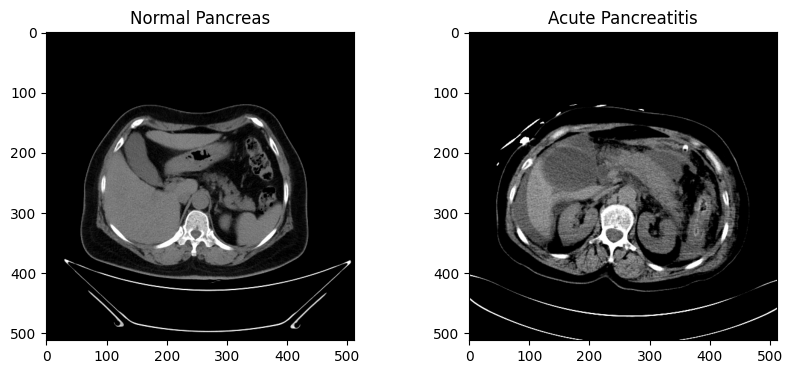

In [2]:
# Example paths (replace with your actual dataset structure)
normal_path = sorted(glob.glob('./Pancreas/NPancreas/*.jpg'))[0]
ap_path = sorted(glob.glob('./Pancreas/PPancreas/*.jpg'))[0]
normal_img = io.imread(normal_path, as_gray=True)
ap_img = io.imread(ap_path, as_gray=True)
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].imshow(normal_img, cmap='gray'); ax[0].set_title('Normal Pancreas')
ax[1].imshow(ap_img, cmap='gray'); ax[1].set_title('Acute Pancreatitis')
plt.show()

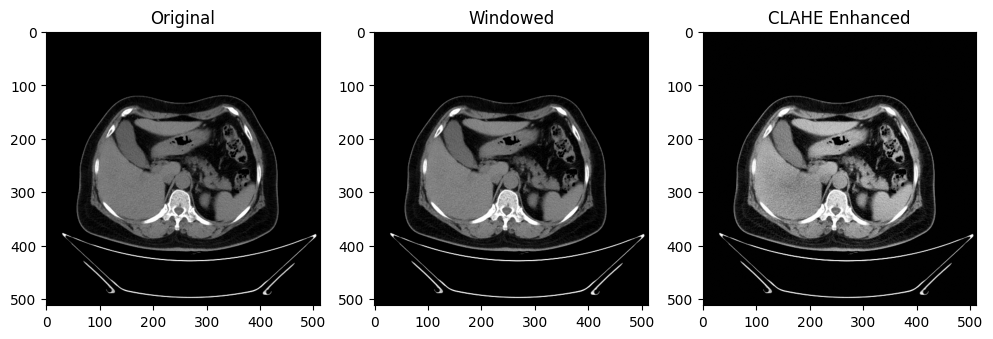

In [3]:
def apply_window(img, level=40, width=400):
    hu_min, hu_max = level - width/2, level + width/2
    scaled = np.clip(img, hu_min, hu_max)
    return ((scaled - hu_min)/(hu_max - hu_min)*255).astype(np.uint8)

def apply_clahe(img):
    clahe = exposure.equalize_adapthist(img/255.0, clip_limit=0.01)
    return (clahe*255).astype(np.uint8)

windowed = apply_window(normal_img*255)
clahe_applied = apply_clahe(windowed)

fig, ax = plt.subplots(1,3, figsize=(12,4))
ax[0].imshow(normal_img, cmap='gray'); ax[0].set_title('Original')
ax[1].imshow(windowed, cmap='gray'); ax[1].set_title('Windowed')
ax[2].imshow(clahe_applied, cmap='gray'); ax[2].set_title('CLAHE Enhanced')
plt.show()

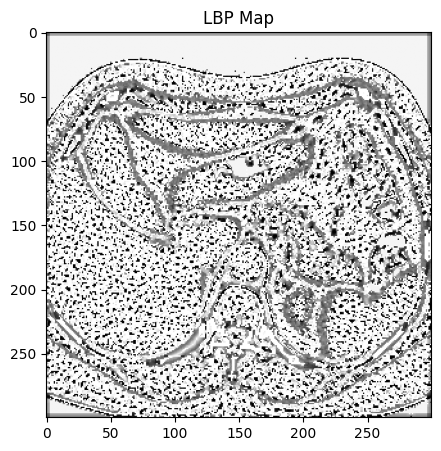

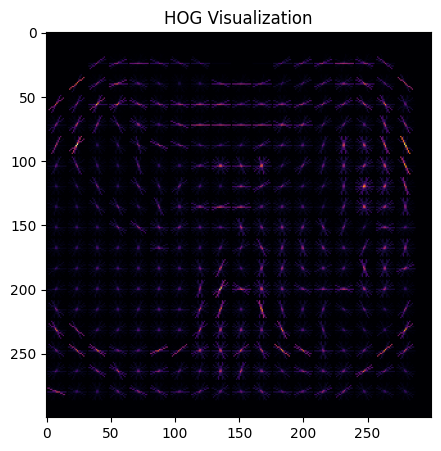

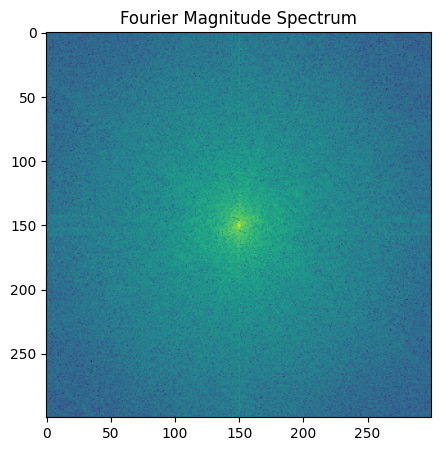

In [4]:
# Feature Visualization
roi = clahe_applied[100:400, 100:400]

# LBP
lbp = feature.local_binary_pattern(roi, P=24, R=3, method='uniform')
plt.imshow(lbp, cmap='gray'); plt.title('LBP Map'); plt.show()

# HOG
hog_img = feature.hog(roi/255.0, orientations=9, pixels_per_cell=(16,16), cells_per_block=(2,2), visualize=True)[1]
plt.imshow(hog_img, cmap='inferno'); plt.title('HOG Visualization'); plt.show()

# Fourier Spectrum
fshift = np.fft.fftshift(np.fft.fft2(roi))
plt.imshow(np.log(np.abs(fshift)+1), cmap='viridis'); plt.title('Fourier Magnitude Spectrum'); plt.show()

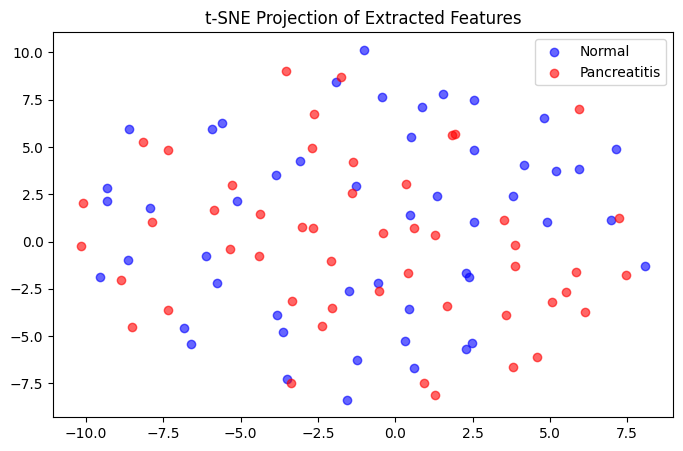

In [5]:
# t-SNE Demo Visualization (using synthetic feature data)
np.random.seed(42)
X = np.random.rand(100, 50)
y = np.array([0]*50 + [1]*50)
X_emb = TSNE(n_components=2, random_state=42, perplexity=20).fit_transform(X)
plt.scatter(X_emb[y==0,0], X_emb[y==0,1], c='blue', label='Normal', alpha=0.6)
plt.scatter(X_emb[y==1,0], X_emb[y==1,1], c='red', label='Pancreatitis', alpha=0.6)
plt.title('t-SNE Projection of Extracted Features')
plt.legend(); plt.show()